In [32]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 1.데이터 업로드

DATA_PATH = "/content/spy_supervised_30d_5d.npz"

if not os.path.exists(DATA_PATH):
    print(f"[{DATA_PATH}] 파일을 찾을 수 없습니다.")
    np.savez(DATA_PATH,
             X=np.random.randn(698, 30, 10).astype(np.float32),
             y=np.random.randint(0, 3, size=(698,)).astype(np.int64))

Using device: cpu


In [19]:
# 2. 데이터셋 로드 및 PyTorch Dataset 정의

class RegimeDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# 데이터 파일 로드
data = np.load(DATA_PATH)
X_all, y_all = data['X'], data['y']
total_samples = len(X_all)

# 시가계열 분리 (Look-ahead bias 방지, 기획서 기준 488 / 105 / 105 분할 비율 적용)
train_size = int(total_samples * 0.70)
valid_size = int(total_samples * 0.15)

X_train, y_train = X_all[:train_size], y_all[:train_size]
X_val, y_val = X_all[train_size:train_size+valid_size], y_all[train_size:train_size+valid_size]
X_test, y_test = X_all[train_size+valid_size:], y_all[train_size+valid_size:]

# DataLoader 생성
batch_size = 32
train_loader = DataLoader(RegimeDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(RegimeDataset(X_val, y_val), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(RegimeDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

print(f"데이터셋 분할 완료 - Train: {len(X_train)}, Valid: {len(X_val)}, Test: {len(X_test)}")

데이터셋 분할 완료 - Train: 488, Valid: 104, Test: 106


In [20]:
# 3. Transformer 기반 국면 분류 모델(RegimeTransformer) 설계

class TimeSeriesPositionalEmbedding(nn.Module):
    """시계열 데이터의 sequential 정렬 정보를 반영하기 위한 학습 가능한 임베딩"""
    def __init__(self, seq_len, d_model):
        super().__init__()
        self.pos_embedding = nn.Parameter(torch.randn(1, seq_len, d_model))

    def forward(self, x):
        return x + self.pos_embedding

class RegimeTransformer(nn.Module):
    def __init__(self, input_dim=10, seq_len=30, num_classes=3, d_model=64, nhead=4, num_layers=2, dim_feedforward=128, dropout=0.2):
        super().__init__()

        # 1. 입력 Feature 차원을 d_model 차원으로 선형 변환 (Projection)
        self.input_projection = nn.Linear(input_dim, d_model)

        # 2. 고정 Positional Encoding 대신 시계열에 유연한 학습형 Positional Embedding 적용
        self.pos_embedding = TimeSeriesPositionalEmbedding(seq_len, d_model)

        self.dropout = nn.Dropout(dropout)

        # 3. Transformer Encoder Layer Stack 정의 (batch_first=True 설정으로 (batch, seq, feature) 대응)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation='relu'
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # 4. Classifier Head: 전체 시계열 토큰의 평균(Global Average Pooling) 후 MLP 연결
        self.classifier = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, num_classes) # Softmax는 CrossEntropyLoss 내부에 포함됨
        )

    def forward(self, x):
        # x shape: (batch, seq_len, input_dim)
        x = self.input_projection(x)          # (batch, seq_len, d_model)
        x = self.pos_embedding(x)             # (batch, seq_len, d_model)
        x = self.dropout(x)

        # Transformer Encoder 통과
        attn_output = self.transformer_encoder(x) # (batch, seq_len, d_model)

        # Global Average Pooling을 취해 시퀀스 차원 축소
        pooled = attn_output.mean(dim=1)      # (batch, d_model)

        # 최종 로짓 출력
        logits = self.classifier(pooled)       # (batch, num_classes)
        return logits

# 모델 인스턴스 생성 및 요약 출력
model = RegimeTransformer(input_dim=10, seq_len=30, num_classes=3).to(device)
print(f"Transformer 파라미터 수: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Transformer 파라미터 수: 71,747


In [21]:
# 4. 학습 및 검증 루프

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

epochs = 30
best_val_loss = float('inf')
best_model_state = None

print("\n--- 모델 학습 시작 ---")
for epoch in range(epochs):
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()

    epoch_train_loss = train_loss / train_total
    epoch_train_acc = train_correct / train_total

    # 검증 단계
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    epoch_val_loss = val_loss / val_total
    epoch_val_acc = val_correct / val_total

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_model_state = model.state_dict().copy()

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc*100:.1f}% | Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc*100:.1f}%")

# 최적 모델 가중치 복원
model.load_state_dict(best_model_state)


--- 모델 학습 시작 ---
Epoch [1/30] | Train Loss: 1.0357 Acc: 52.3% | Val Loss: 0.7653 Acc: 75.0%
Epoch [5/30] | Train Loss: 0.8536 Acc: 62.3% | Val Loss: 0.6998 Acc: 72.1%
Epoch [10/30] | Train Loss: 0.7972 Acc: 64.8% | Val Loss: 0.8260 Acc: 69.2%
Epoch [15/30] | Train Loss: 0.7647 Acc: 67.6% | Val Loss: 0.7843 Acc: 71.2%
Epoch [20/30] | Train Loss: 0.7192 Acc: 69.3% | Val Loss: 0.9221 Acc: 64.4%
Epoch [25/30] | Train Loss: 0.6954 Acc: 70.3% | Val Loss: 1.0396 Acc: 66.3%
Epoch [30/30] | Train Loss: 0.6478 Acc: 73.2% | Val Loss: 1.0091 Acc: 68.3%


<All keys matched successfully>

In [34]:
# 5. 테스트셋 평가 (각 클래스별 정확도 및 F1-score 산출)
from sklearn.metrics import f1_score

model.eval()
test_preds = []
test_probs = []

with torch.no_grad():
    for inputs, _ in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)

        test_preds.extend(predicted.cpu().numpy())
        test_probs.extend(probs.cpu().numpy())

test_preds = np.array(test_preds)
test_probs = np.array(test_probs)

print("\n--- Test Set 클래스별 성능 평가 (Acc & F1-score) ---")

# 1. 혼동 행렬 및 F1-score 계산
cm = confusion_matrix(y_test, test_preds)
individual_f1s = f1_score(y_test, test_preds, average=None)
macro_f1 = f1_score(y_test, test_preds, average='macro')

# 각 클래스별 이름 정의
class_names = ['Bear (0)', 'Neutral (1)', 'Bull (2)']

# 2. 클래스별 정확도 및 F1-score 출력
for i, name in enumerate(class_names):
    total_samples = np.sum(cm[i, :])

    if total_samples > 0:
        correct_samples = cm[i, i]
        class_acc = (correct_samples / total_samples) * 100
        class_f1 = individual_f1s[i]

        print(f"{name} - Accuracy: {class_acc:.2f}% ({correct_samples}/{total_samples}) | f1-score: {class_f1:.2f}")
    else:
        print(f"{name} - 데이터 없음")

print("-" * 60)
print(f"최종 Macro f1-score (전체 평균): {macro_f1:.2f}")


--- Test Set 클래스별 성능 평가 (Acc & F1-score) ---
Bear (0) - Accuracy: 32.56% (14/43) | f1-score: 0.42
Neutral (1) - Accuracy: 13.64% (3/22) | f1-score: 0.16
Bull (2) - Accuracy: 92.68% (38/41) | f1-score: 0.70
------------------------------------------------------------
최종 Macro f1-score (전체 평균): 0.43


In [28]:
# 6. 포트폴리오 동적 자산배분 백테스트 (Test Set)

print("\n--- 포트폴리오 백테스트 구동 ---")

# [수정] 가상의 자산 가격 데이터 대신 제공된 spy_daily.csv의 실제 데이터를 로드하여 사용합니다.
# 1. 일별 원본 데이터 로드
df_daily = pd.read_csv("spy_daily.csv")

# 2. HMM 라벨 생성 규칙에 맞춰 데이터의 가장 마지막 날짜부터 역산하여 5거래일 간격으로 샘플링합니다.
# 끝에서부터 5일 간격으로 인덱스를 추출한 뒤, 다시 시간 순서대로 정렬합니다.
indices = np.arange(len(df_daily) - 1, -1, -5)[::-1]
df_5d = df_daily.iloc[indices].copy()

# 3. 배당 및 분할이 반영된 수정 종가(Adj Close)를 기반으로 5거래일 간의 실제 수익률을 계산합니다.
df_5d['return_5d'] = df_5d['Adj Close'].pct_change()

# 4. 전체 5일 주기 데이터 중 가장 마지막 구간인 Test Set 크기만큼 슬라이싱하여 실제 수익률 배열을 확보합니다.
spy_test_returns = df_5d['return_5d'].iloc[-len(y_test):].values

# (안전장치) 혹시 모를 누락 데이터(NaN)가 존재할 경우 0으로 대체합니다.
spy_test_returns = np.nan_to_num(spy_test_returns)

# 모델 출력 확률: [p_bear, p_neutral, p_bull]
p_bear = test_probs[:, 0]
p_neutral = test_probs[:, 1]
p_bull = test_probs[:, 2]

# 기획서 제안 가중치 수식 적용: w_stock = p_bull + 0.5 * p_neutral
w_stock = p_bull + 0.5 * p_neutral
w_cash = 1.0 - w_stock

# 편도 거래비용 가정 (기획서 기준 0.1%)
transaction_cost_fee = 0.001
portfolio_returns = []
prev_w_stock = 0.0

for i in range(len(y_test)):
    # 5거래일 간격 리밸런싱이지만 데이터셋 샘플링 자체가 5일 간격이므로 매 스텝 가중치 변경 반영
    current_w_stock = w_stock[i]

    # 자산배분 포트폴리오 당기 수익률 계산 (현금 수익률은 0% 가정)
    raw_return = current_w_stock * spy_test_returns[i]

    # 가중치 변경에 따른 회전율 기반 거래 비용 차감
    turnover = abs(current_w_stock - prev_w_stock)
    cost = turnover * transaction_cost_fee

    portfolio_returns.append(raw_return - cost)
    prev_w_stock = current_w_stock

portfolio_returns = np.array(portfolio_returns)

# 벤치마크 계산 (Buy & Hold 및 60/40)
benchmark_bh_returns = spy_test_returns
benchmark_6040_returns = 0.6 * spy_test_returns

# 누적 수익률 계산
cum_portfolio = np.cumprod(1 + portfolio_returns) - 1
cum_bh = np.cumprod(1 + benchmark_bh_returns) - 1
cum_6040 = np.cumprod(1 + benchmark_6040_returns) - 1


--- 포트폴리오 백테스트 구동 ---


In [30]:
# 7. 성과 지표 산출 계산기 (Sharpe, MDD 등)

def calculate_metrics(returns, cum_returns, name="Strategy"):
    # 5거래일 주기 데이터이므로 연율화 계수는 대략 52를 사용 (252일 / 5)
    ann_factor = 52
    ann_return = np.mean(returns) * ann_factor
    ann_vol = np.std(returns) * np.sqrt(ann_factor)
    sharpe = ann_return / ann_vol if ann_vol != 0 else 0

    # Max Drawdown 계산
    peaks = np.maximum.accumulate(cum_returns + 1)
    drawdowns = (cum_returns + 1) / peaks - 1
    mdd = np.min(drawdowns)

    # Calmar Ratio
    calmar = ann_return / abs(mdd) if mdd != 0 else 0

    return {
        "전략명": name,
        "누적수익률(%)": f"{cum_returns[-1]*100:.2f}%",
        "연율화수익률(%)": f"{ann_return*100:.2f}%",
        "연율화변동성(%)": f"{ann_vol*100:.2f}%",
        "Sharpe Ratio": f"{sharpe:.2f}",
        "MDD(%)": f"{mdd*100:.2f}%",
        "Calmar Ratio": f"{calmar:.2f}"
    }

results = [
    calculate_metrics(portfolio_returns, cum_portfolio, "Transformer Dynamic"),
    calculate_metrics(benchmark_bh_returns, cum_bh, "Buy & Hold (SPY 100%)"),
    calculate_metrics(benchmark_6040_returns, cum_6040, "Static 60/40")
]

# 성과 비교 테이블 출력
print("\n[최종 백테스트 성과 비교]")
print(pd.DataFrame(results).to_string(index=False))


[최종 백테스트 성과 비교]
                  전략명 누적수익률(%) 연율화수익률(%) 연율화변동성(%) Sharpe Ratio  MDD(%) Calmar Ratio
  Transformer Dynamic   22.81%    10.33%     6.96%         1.49  -5.44%         1.90
Buy & Hold (SPY 100%)   47.57%    20.10%    13.97%         1.44 -13.80%         1.46
         Static 60/40   26.93%    12.06%     8.38%         1.44  -8.44%         1.43


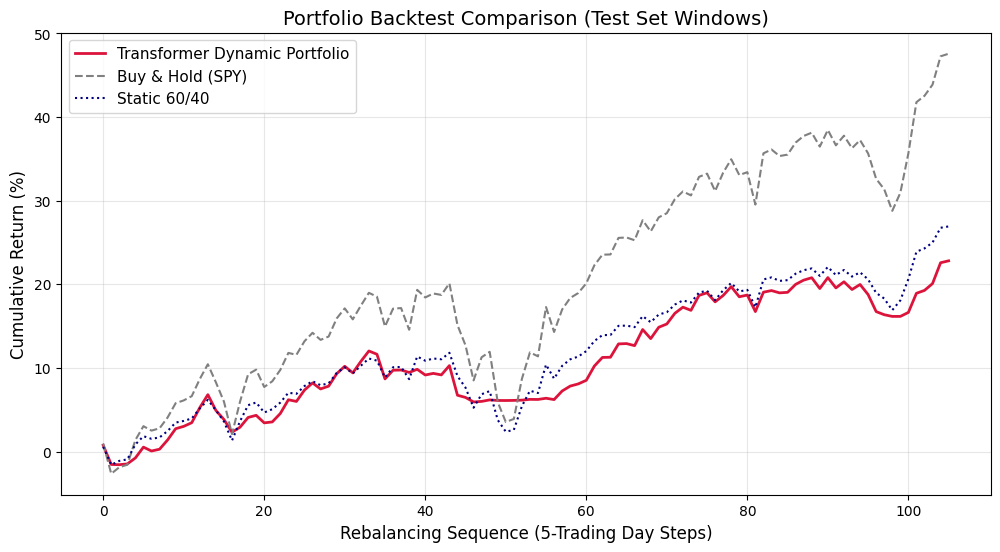

In [31]:
# 8.결과 시각화 차트 그리기

plt.figure(figsize=(12, 6))
plt.plot(cum_portfolio * 100, label='Transformer Dynamic Portfolio', color='crimson', lw=2)
plt.plot(cum_bh * 100, label='Buy & Hold (SPY)', color='gray', linestyle='--')
plt.plot(cum_6040 * 100, label='Static 60/40', color='navy', linestyle=':')
plt.title('Portfolio Backtest Comparison (Test Set Windows)', fontsize=14)
plt.xlabel('Rebalancing Sequence (5-Trading Day Steps)', fontsize=12)
plt.ylabel('Cumulative Return (%)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()